In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pyod.models.iforest import IForest
import numpy as np

In [3]:
hospice_data = pd.read_csv(r'C:\Users\prana\Downloads\hospice_data.csv')
hospice_data

,BILLING_PROVIDER_NPI_NUM,SERVICING_PROVIDER_NPI_NUM,HCPCS_CODE,CLAIM_FROM_MONTH,TOTAL_UNIQUE_BENEFICIARIES,TOTAL_CLAIMS,TOTAL_PAID,claim_year,claim_month,claim_yyyymm
0,1528615465,1528615465,Q5001,2024-06,42,43,0.0,2024,6,202406
1,1942860648,1942860648,Q5001,2024-02,13,13,0.0,2024,2,202402
2,1710173166,1710173166,Q5001,2024-06,16,16,0.0,2024,6,202406
3,1376583617,1376583617,Q5001,2020-07,18,18,0.0,2020,7,202007
4,1528153244,1528153244,Q5001,2024-08,13,15,0.0,2024,8,202408
...,...,...,...,...,...,...,...,...,...,...
314,1245825975,1134190713,Q5004,2022-07,14,122,0.0,2022,7,202207
315,1245825975,1134190713,Q5004,2022-08,18,114,0.0,2022,8,202208
316,1245825975,1134190713,Q5004,2022-12,13,18,0.0,2022,12,202212
317,1245825975,1134190713,Q5004,2022-10,13,20,0.0,2022,10,202210


In [4]:
X = hospice_data.drop(columns=['BILLING_PROVIDER_NPI_NUM', 'SERVICING_PROVIDER_NPI_NUM', 'HCPCS_CODE', 'CLAIM_FROM_MONTH', 'TOTAL_UNIQUE_BENEFICIARIES', 'claim_year', 
                       'claim_month', 'claim_yyyymm'])

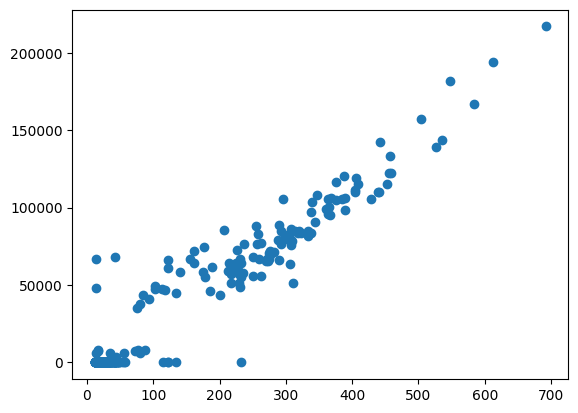

In [5]:
plt.scatter(X.iloc[:, 0], X.iloc[:,1])

In [6]:
clf_name = 'IsolationForest'
clf = IForest(contamination=.01, random_state=42)
clf.fit(X)


,n_estimators,100
,max_samples,'auto'
,contamination,0.01
,max_features,1.0
,bootstrap,False
,n_jobs,1
,behaviour,'old'
,random_state,42
,verbose,0


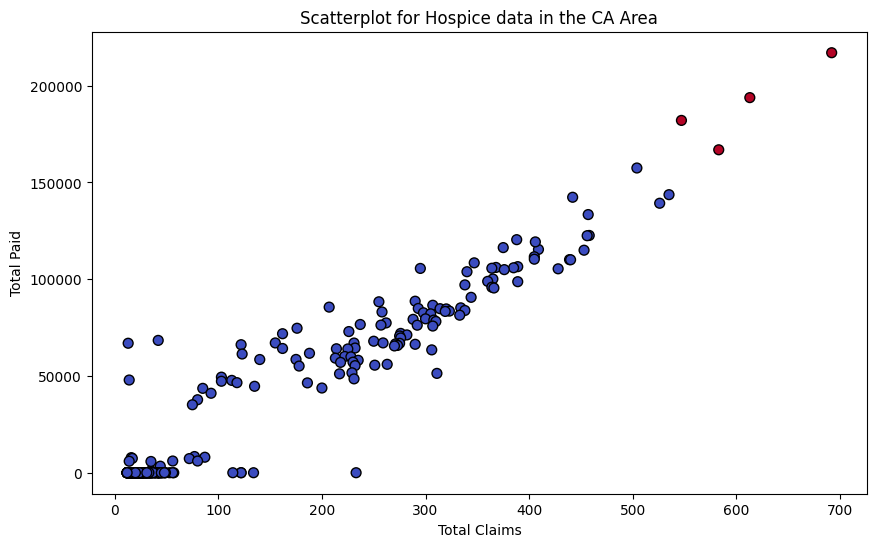

In [8]:
y_pred = clf.labels_
y_scores = clf.decision_scores_
outliers = X[y_pred == 1]
plt.figure(figsize=(10, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y_pred, cmap='coolwarm',s=50, edgecolors='k')
plt.title(f'Scatterplot for Hospice data in the CA Area')
plt.xlabel('Total Claims')
plt.ylabel('Total Paid')
plt.show()

In [13]:
print(np.sort(y_scores)[-4:])

[0.00678069 0.00817536 0.05631072 0.10705884]


In [15]:
X_results = X.copy()
X_results['outlier_score'] = clf.decision_scores_
X_results['is_outlier'] = clf.labels_

top_t_outliers = X_results.nlargest(4, 'outlier_score')

print(top_t_outliers)

    TOTAL_CLAIMS  TOTAL_PAID  outlier_score  is_outlier
5            692   217034.03       0.107059           1
6            613   193831.98       0.056311           1
8            547   182058.89       0.008175           1
10           583   166876.07       0.006781           1
